# Gaussian mixtures and expectation–maximization
We fit standardized vehicle weight and fuel economy. The first implementation exposes every E- and M-step before comparison with scikit-learn.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/16-latent-variables-em/'
for _name in ['Auto.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

auto=pd.read_csv('Auto.csv',na_values='?').dropna(subset=['weight','mpg'])
raw=auto[['weight','mpg']].to_numpy(float)
X=StandardScaler().fit_transform(raw)
auto[['name','weight','mpg']].head(),X.shape

(                        name  weight   mpg
 0  chevrolet chevelle malibu    3504  18.0
 1          buick skylark 320    3693  15.0
 2         plymouth satellite    3436  18.0
 3              amc rebel sst    3433  16.0
 4                ford torino    3449  17.0,
 (397, 2))

## Spherical Gaussian EM from scratch
Responsibilities are computed in log space. A declared variance floor prevents singular components.

In [2]:
def log_gaussian(X,mean,var):
    d=X.shape[1]
    return -.5*(d*np.log(2*np.pi*var)+((X-mean)**2).sum(axis=1)/var)

def spherical_em(X,K,seed=0,steps=100,var_floor=.025):
    rng=np.random.default_rng(seed)
    means=X[rng.choice(len(X),K,replace=False)].copy()
    variances=np.repeat(np.var(X),K); weights=np.repeat(1/K,K); history=[]
    for _ in range(steps):
        log_joint=np.column_stack([np.log(weights[k])+log_gaussian(X,means[k],variances[k]) for k in range(K)])
        log_norm=logsumexp(log_joint,axis=1)
        gamma=np.exp(log_joint-log_norm[:,None]); history.append(log_norm.sum())
        counts=gamma.sum(axis=0); weights=counts/len(X); means=gamma.T@X/counts[:,None]
        variances=np.array([(gamma[:,k,None]*(X-means[k])**2).sum()/(X.shape[1]*counts[k]) for k in range(K)])
        variances=np.maximum(variances,var_floor)
    return means,variances,weights,gamma,np.array(history)

fits=[spherical_em(X,3,26519+r) for r in range(20)]
means,variances,weights,gamma,history=max(fits,key=lambda fit:fit[-1][-1])
weights,variances,history[-1],np.all(np.diff(history)>=-1e-8)

(array([0.22280389, 0.34773011, 0.429466  ]),
 array([0.12313021, 0.19571363, 0.29070228]),
 np.float64(-860.1202392578139),
 np.True_)

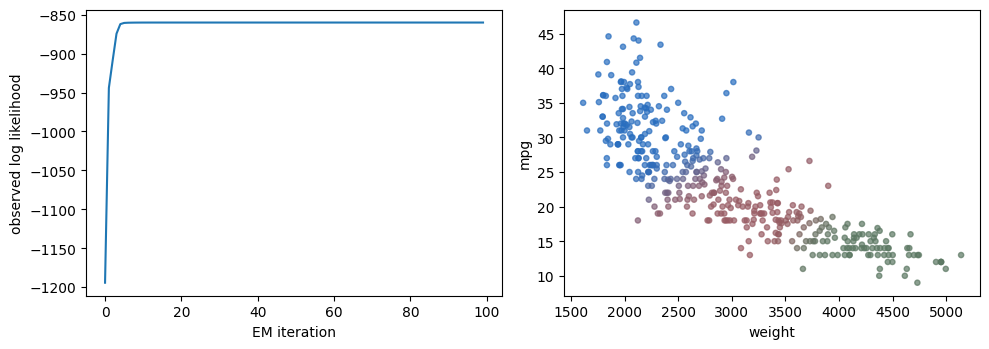

In [3]:
order=np.argsort(means[:,0]); colors=gamma[:,order]@np.array([[0.16,0.43,0.75],[0.60,0.36,0.39],[0.36,0.47,0.39]])
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
axes[0].plot(history); axes[0].set(xlabel='EM iteration',ylabel='observed log likelihood')
axes[1].scatter(raw[:,0],raw[:,1],c=colors,s=14,alpha=.7); axes[1].set(xlabel='weight',ylabel='mpg')
plt.tight_layout()

## Compare with the library implementation
The library supports richer covariance families and multiple restarts. Its parameterization need not match our spherical model exactly.

In [4]:
library=GaussianMixture(n_components=3,covariance_type='spherical',n_init=20,reg_covar=.025,random_state=26519).fit(X)
{'scratch_total_loglik':history[-1],'library_total_loglik':library.score(X)*len(X),'library_converged':library.converged_}

{'scratch_total_loglik': np.float64(-860.1202392578139),
 'library_total_loglik': np.float64(-864.3763506481248),
 'library_converged': True}